In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import funcs as funcs
import params
import scipy.io as sio
import math
from datetime import date
import datetime
import pandas as pd
from netCDF4 import Dataset

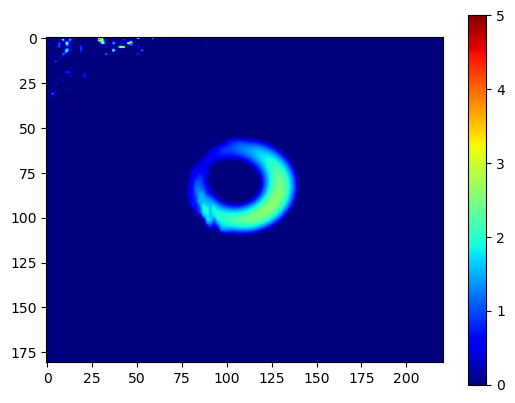

In [2]:
nt = 4
monthplot, dayplot, hourplot = 9, 20, 8
rainrate = funcs.rainfieldx(nt,monthplot,dayplot,hourplot)
# rainrate = funcs.rainfieldx(55,8,26,8)
plt.imshow(np.flipud(rainrate),cmap='jet'); plt.colorbar()

In [3]:
mat = sio.loadmat('data/temp.mat')
latstore = mat['latstore']
longstore = mat['longstore']
vstore = mat['vstore']
rmstore = mat['rmstore']
vsestore = mat['vsestore']
rmsestore = mat['rmsestore']
u850store = mat['u850store']
v850store = mat['v850store']
ut, vt, jmax = funcs.utrans(latstore, longstore)

In [4]:
x,y,netrain = funcs.rainswathx(50,latstore,longstore,rmstore,vstore,rmsestore,vsestore,ut,vt,u850store,v850store)

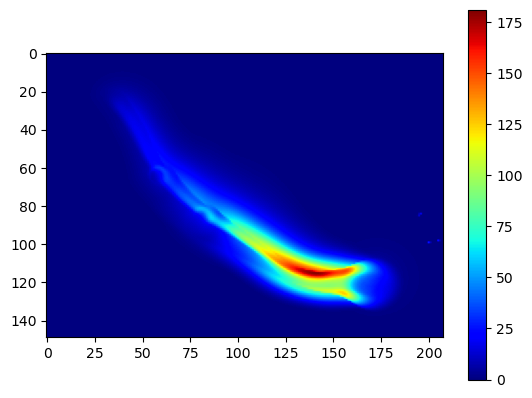

In [5]:
plt.imshow(np.flipud(netrain[:,:,0]),cmap='jet'); plt.colorbar()

In [10]:
netrain.shape

(149, 208, 1)

In [5]:
nc_fid = Dataset('/Users/pvn/research/STUDY/Projects/DOE/SETx-UIFL/TC_Downscaling/Downscaled/tracks_NA_ACCESS-CM2_historical_r1i1p1f1_196401_201412.nc', 'r')
nc_fid.variables.keys()

dict_keys(['lon_trks', 'lat_trks', 'u250_trks', 'v250_trks', 'u850_trks', 'v850_trks', 'v_trks', 'm_trks', 'vmax_trks', 'tc_month', 'tc_basins', 'tc_years', 'seeds_per_month', 'n_trk', 'time', 'year', 'basin', 'month'])

In [6]:
lon_trks = nc_fid.variables['lon_trks'][:]
lat_trks = nc_fid.variables['lat_trks'][:]
v_trks = nc_fid.variables['v_trks'][:]
vmax_trks = nc_fid.variables['vmax_trks'][:]


In [7]:
# def Calculate_max_radius(phi,Pc,Vt):
#     vars = (0.0873 * (phi-28) + 12.22*np.exp((pcg-1013.2)/33.86) + 0.2*Vt + 37.22) * np.pi/180
#     rm = 28.52 * np.tanh(vars)
#     return rm

In [8]:
ro = 1000.          # Outer radius
wc = 3.0            # Radiative subsidence rate
cdouter = 1.2e-3    # Drag coefficient
# drouter = 0.002     # 
nouter = 1000       # Number of radial point

rmstore2 = np.zeros(vstore.shape)
for ind in range(1000):
    jmax = np.argmin(vstore[ind,:])
    pcg = np.zeros(jmax)
    for jnd in range(jmax):
        alats = latstore[ind,jnd]
        vsin = vstore[ind,jnd]
        fc1 = 1.45e-4 * np.abs(alats * 0.0175)
        vouter, rm, imin = funcs.vouternew(vsin,fc1,ro,wc,cdouter,nouter)
        rmstore2[ind,jnd] = rm
                
    if ind % 100 == 0:
        print(ind)
        

0
100
200
300
400
500
600
700
800
900


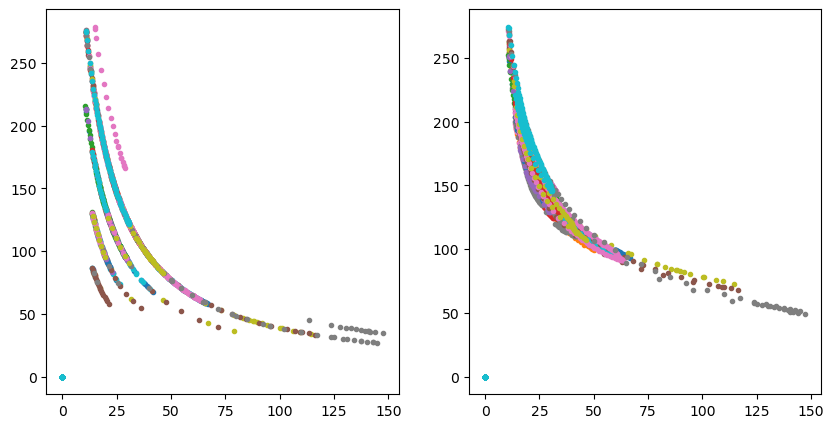

In [9]:
colors = ['k','r','b','g','m','k']
ntall = np.random.choice(1000, 20)
fig,ax = plt.subplots(1,2,figsize=(10,5))
for k, nt in enumerate(ntall):
    ax[0].plot(vstore[nt,:],rmstore[nt,:],'o',ms=3)
    ax[1].plot(vstore[nt,:],rmstore2[nt,:],'o',ms=3)

In [111]:
ind = 0
jmax = np.argmin(vstore[ind,:])
phi = latstore[ind,:jmax]
Vt = vt[ind,:jmax]
rmm = Calculate_max_radius(phi,pcg,Vt)

In [13]:
np.nonzero(longstore[0,:])

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134]),)